# Describing the molecule

**Chapter focus**

> How do we specify a molecular system and construct the starting wavefunction for the correlated calculation?

## Learning objectives

After completing this chapter, you will be able to:

- Specify a molecule by its geometry, charge, and spin multiplicity.
- Explain the role of a finite atomic-orbital basis set.
- Describe the Hartree–Fock approximation and the Slater-determinant form of its wavefunction.
- Generate a Hartree–Fock wavefunction with the built-in QDK/Chemistry self-consistent field solver.
- Interpret an energy change caused by changing the basis set.

**Lab notebook assignment**

> Complete *lab notebook molecule* in the lab notebook as you work through this chapter.
> Record the molecular inputs and both Hartree–Fock energies before calculating their difference.
> Interpret the difference as basis-set sensitivity rather than as the total error of either energy.

## Before you begin

This course requires a Python environment with the `qdk-chemistry[jupyter]` package.

`qdk-chemistry` ships compiled binaries for Linux, macOS on Apple silicon, and Windows on x86-64. On Windows on Arm, run this course inside WSL. Run the cell below to check the current environment.

In [ ]:
from _unit import check_env

check_env()

## Setting up

The cell below imports the QDK/Chemistry pieces this chapter uses and quiets the solver logs.

In [ ]:
from qdk_chemistry.algorithms import create
from qdk_chemistry.constants import HARTREE_TO_KJ_PER_MOL
from qdk_chemistry.data import Structure
from qdk_chemistry.utils import Logger

if __name__ == "__main__":
    Logger.set_global_level(Logger.LogLevel.off)

## The molecular system

An electronic-structure calculation requires the identities and positions of the nuclei, the number of electrons, and the target spin state.
This chapter specifies those inputs for the stretched N<sub>2</sub> molecule introduced on the *tutorial landing page*.

The molecular geometry contains two nitrogen atoms separated by $1.85\ \text{Å}$, compared with the [equilibrium bond length](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7727379&Mask=1000) of $1.097685\ \text{Å}$.
The molecule is neutral, so its net charge is zero and it has 14 electrons.
[Spin multiplicity](<https://en.wikipedia.org/wiki/Multiplicity_(chemistry)>) is defined as $2S+1$, where $S$ is the total electron spin produced by combining the spins of all electrons.
Paired electrons contribute no net spin, whereas unpaired electrons can produce $S>0$.
A multiplicity of one, two, or three is called a singlet, doublet, or triplet, respectively.
The labels $\alpha$ and $\beta$ denote spin projections $+\tfrac{1}{2}$ (spin up) and $-\tfrac{1}{2}$ (spin down), respectively.
QDK/Chemistry uses the molecular charge and spin multiplicity to determine the numbers of $\alpha$ and $\beta$ electrons in the calculation.
For the target N<sub>2</sub> singlet, $S=0$, so the multiplicity is one and the calculation contains seven $\alpha$ and seven $\beta$ electrons.

QDK/Chemistry represents a molecular geometry with a `Structure` object.
This example constructs the `Structure` object from a string in [XYZ file format](https://en.wikipedia.org/wiki/XYZ_file_format), which contains an atom count, a comment line, and one element symbol with three Cartesian coordinates for each atom:

In [ ]:
structure = Structure.from_xyz("""\
2
Stretched N2 molecule for the ground-state QPE tutorial
N    0.000000    0.000000    0.000000
N    0.000000    0.000000    1.850000
""")
# The 1.85-Angstrom bond is substantially longer than the 1.097685-Angstrom
# equilibrium distance, increasing multiconfigurational character.
# The target is neutral N2 in its singlet ground state, where all electrons are
# paired and the spin multiplicity 2S + 1 equals one.
charge = 0
spin_multiplicity = 1

The XYZ format used by QDK/Chemistry interprets coordinates in ångström units.
However, this format does not specify molecular charge or spin multiplicity, so the example records these values separately.

## The mean-field wavefunction

The [Hartree–Fock method](https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method) approximates the many-electron wavefunction with one [Slater determinant](https://en.wikipedia.org/wiki/Slater_determinant).
As introduced in the *tutorial overview*, each occupied spin orbital combines a spatial molecular orbital with an $\alpha$ or $\beta$ spin function.
Let $\psi_p(x)$ denote occupied spin orbital $p$, where $x=(\mathbf{r},\sigma)$ contains a spatial coordinate $\mathbf{r}$ and a spin label $\sigma\in\{\alpha,\beta\}$.
For an $N$-electron Hartree–Fock state, the occupied spin orbitals form the Slater determinant

$$
\Phi_{\mathrm{HF}}(x_1,\ldots,x_N)
=\frac{1}{\sqrt{N!}}
\det\!\left[\psi_p(x_q)\right]_{q,p=1}^{N}.
$$

Here $\det$ denotes the determinant of the matrix whose row $q$ evaluates every occupied spin orbital at electron coordinate $x_q$.
The factor $1/\sqrt{N!}$ normalizes the wavefunction when the occupied spin orbitals are orthonormal.
Exchanging two electron coordinates swaps two matrix rows and changes the sign of $\Phi_{\mathrm{HF}}$, enforcing fermionic antisymmetry.
This determinant is an *approximate* many-electron wavefunction.
Each electron interacts with the average field generated by the other electrons rather than with their instantaneous correlated motion.
This mean-field treatment makes Hartree–Fock computationally tractable because it avoids representing all possible electron configurations.
The determinant accounts for exchange, an effect of wavefunction antisymmetry that reduces the probability of finding same-spin electrons together, but it omits electron correlation.

The Hartree–Fock energy is the fixed-geometry total energy evaluated with the optimized Hartree–Fock determinant:

$$
E_{\mathrm{HF}}
= \langle \Phi_{\mathrm{HF}} \vert \hat{H}_{\mathrm{electronic}} \vert \Phi_{\mathrm{HF}} \rangle
+ E_{\mathrm{nuclear}},
$$

where $\Phi_{\mathrm{HF}}$ is the optimized determinant and $E_{\mathrm{nuclear}}$ is the repulsion among the fixed nuclei.
This energy remains approximate because the determinant cannot represent electron correlation.

## Finite-basis orbital representation

The Hartree–Fock wavefunction $\Phi_{\mathrm{HF}}$ is a determinant constructed from occupied spin orbitals.
Each spin orbital combines a spatial molecular orbital with an $\alpha$ or $\beta$ spin function.
The molecular orbitals are functions of position that provide the spatial parts of these spin orbitals.
Changing the occupied molecular orbitals changes the Hartree–Fock determinant and its many-electron wavefunction.
Because the Hartree–Fock determinant is built from one-electron functions, optimizing the many-electron wavefunction reduces to optimizing these molecular orbitals.
Their spatial shapes and occupations also help identify bonding and antibonding interactions, and the optimized orbitals provide the starting representation for later multi-configurational calculations.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>What is a molecular orbital, and why is it useful?</b></summary>

A molecular orbital is a one-electron spatial function used to construct the spin orbitals in a Hartree–Fock determinant.
Molecular orbitals make the approximate many-electron wavefunction computationally tractable, help interpret bonding and occupations, and provide the starting representation for later multi-configurational calculations.

</details>
</div>

Electronic-structure calculations expand each molecular orbital $\phi_p$ in a finite collection of known basis functions $\{\chi_\mu\}$:

$$
\phi_p(\mathbf{r}) = \sum_\mu c_{\mu p}\chi_\mu(\mathbf{r}).
$$

The index $p$ labels a molecular orbital, and $\mu$ labels a basis function.
The coefficients $c_{\mu p}$ determine molecular orbital $p$, and the self-consistent field calculation optimizes these coefficients.
The collection of basis functions is called a [basis set](<https://en.wikipedia.org/wiki/Basis_set_(chemistry)>).

The following isosurfaces illustrate this construction for stretched N<sub>2</sub>.
Blue and orange distinguish opposite signs of each spatial function; they do not represent positive and negative charge.
The purple spheres mark the nitrogen nuclei.

![Three panels show cc-pVDZ basis-function isosurfaces centered on one of two nitrogen nuclei. From left to right, they are a spherical 2s function, a two-lobed 2p-y function, and a 3d-z-squared function with two axial lobes and a ring. Blue and orange surfaces mark opposite signs of each spatial function, not opposite electric charges.](attachment:tutorial_qpe_atomic_basis_functions.png)

*Selected `cc-pvdz` atomic basis functions (left to right): $2s$, $2p_y$, and $3d_{z^2}$.*

Combining atom-centered basis functions with different coefficients produces molecular orbitals that can extend across both nuclei:

![Three panels show example molecular-orbital isosurfaces formed from the atom-centered basis functions. Each orbital has lobes extending across both nitrogen nuclei. Blue and orange surfaces mark opposite signs of the spatial orbital, not opposite electric charges.](attachment:tutorial_qpe_example_molecular_orbitals.png)

*Example molecular orbitals formed from linear combinations of atom-centered basis functions.*

A finite basis restricts the shapes available to the molecular orbitals and therefore introduces another approximation in the electronic description of the system.
Adding suitable basis functions gives the orbitals more flexibility, but it also increases computational cost.

This chapter compares the correlation-consistent polarized valence double-zeta basis set, `cc-pvdz`, with the related triple-zeta basis set, `cc-pvtz`.
Here, double-zeta and triple-zeta mean that two or three radial functions, respectively, describe each valence atomic orbital.
The larger basis gives the orbitals more radial flexibility but increases computational cost; both basis sets include polarization functions.

This comparison does not determine the exact basis-set error.
It measures how much the Hartree–Fock energy changes with basis size while the geometry, method, and basis-set family remain fixed.

![Flow from one-electron functions to many-electron wavefunctions. Nucleus-centered basis functions combine into spatial molecular orbitals; pairing a spatial orbital with alpha or beta spin gives a spin orbital. Choosing occupied spin orbitals defines an electron configuration, and its antisymmetric state is a Slater determinant. Hartree–Fock uses one optimized determinant, while a multiconfigurational wavefunction combines several determinants with coefficients.](attachment:tutorial_qpe_wavefunction_hierarchy.png)

*Basis functions build molecular orbitals with spin; occupied orbitals define determinants, which form one-determinant or multiconfigurational many-electron wavefunctions.*
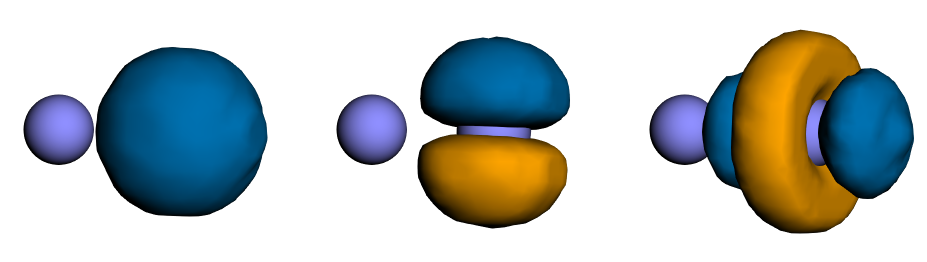
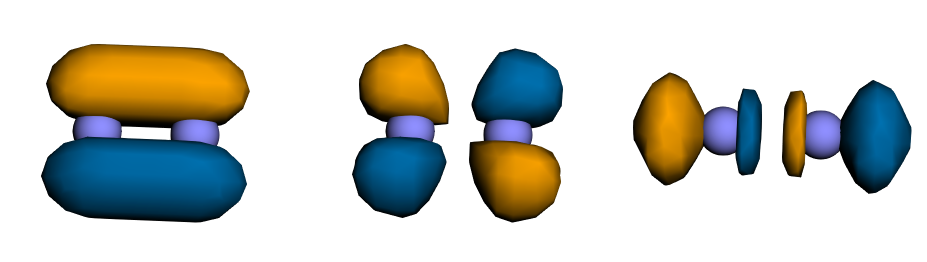
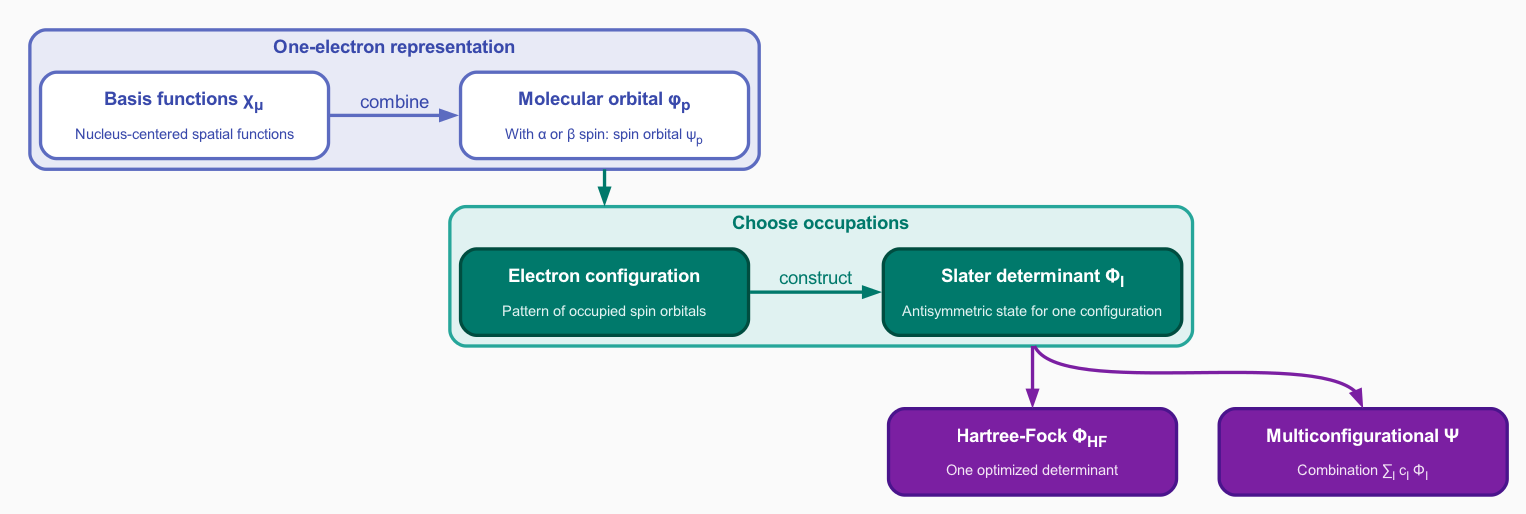

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Which basis set gives a lower energy and why?</b></summary>

The `cc-pvtz` calculation gives the lower energy.
This result is consistent with its additional radial flexibility, which provides a more flexible representation of the molecular orbitals.
The atomic elements and coordinates, molecular net charge, spin multiplicity, and Hartree–Fock method remain fixed, so the observed difference measures basis-set sensitivity.

</details>
</div>

## Self-consistent wavefunction optimization

The occupied molecular orbitals determine the average distribution of the electrons in the Hartree–Fock determinant.
This distribution generates the effective field that represents the average interaction of each electron with the others, as described above.
Solving the one-electron equations in that field produces new molecular orbitals and therefore a new electron distribution and field.
The [self-consistent field](https://en.wikipedia.org/wiki/Self-consistent_field) (SCF) procedure resolves this dependence iteratively:

1. Begin with an initial set of molecular orbitals.
2. Construct the effective one-electron operator generated by those orbitals.
3. Solve for an updated set of orbitals.
4. Repeat until the energy and orbitals satisfy the convergence criteria.

The QDK/Chemistry `ScfSolver` returns the converged fixed-geometry total energy and a wavefunction containing the self-consistent molecular orbitals.
These orbitals provide the starting point for the multi-configurational calculations introduced in *Choosing the active space*.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>Why does a Hartree–Fock calculation require an iterative SCF procedure?</b></summary>

The molecular orbitals determine the mean field experienced by each electron, while that mean field determines the molecular orbitals.
SCF iterations update the orbitals and field until they are mutually consistent.

</details>
</div>

## Running the calculation

The following code runs the built-in QDK/Chemistry Hartree–Fock solver once for each basis set.
The primary result is the `cc-pvdz` wavefunction, whose self-consistent molecular orbitals serve as the starting point for the multi-configurational calculation in *Choosing the active space*.
The `cc-pvdz` and `cc-pvtz` Hartree–Fock energies support the basis-set sensitivity exercise that follows.

In [ ]:
# Correlation-consistent double- and triple-zeta bases form a controlled sequence:
# cc-pVTZ adds radial/angular flexibility beyond cc-pVDZ at higher cost.
basis_sets = ("cc-pvdz", "cc-pvtz")
# Store each result under its basis-set name so the values from the shared loop
# can be compared afterward without repeating either calculation.
energies = {}
wavefunctions = {}

# Change only the basis set so the energy difference measures basis-set sensitivity.
for basis_set in basis_sets:
    solver = create("scf_solver", "qdk")
    # basis_or_guess accepts either a basis name or a reusable orbital guess.
    # Supplying a string asks the solver to build that basis from the structure.
    # run() returns the converged total energy and its Hartree--Fock wavefunction.
    energy, wavefunction = solver.run(
        structure,
        charge=charge,
        spin_multiplicity=spin_multiplicity,
        basis_or_guess=basis_set,
    )
    energies[basis_set] = energy
    wavefunctions[basis_set] = wavefunction
    print(f"{basis_set}: {energy:.12f} Hartree")

# Record the continued workflow's orbital count. The active-space workflow later
# selects a subset, and each retained spatial orbital contributes two spin modes.
num_cc_pvdz_orbitals = (
    wavefunctions["cc-pvdz"].get_orbitals().get_num_molecular_orbitals()
)
print(f"cc-pvdz wavefunction: {num_cc_pvdz_orbitals} molecular orbitals")

In [ ]:
signed_difference = energies["cc-pvtz"] - energies["cc-pvdz"]

# Report the same absolute sensitivity in milliHartree and kJ/mol, a common
# chemical-energy unit obtained with the library's Hartree conversion constant.
absolute_difference_millihartree = abs(signed_difference) * 1000
absolute_difference_kj_mol = abs(signed_difference) * HARTREE_TO_KJ_PER_MOL

print(f"Signed difference (cc-pVTZ - cc-pVDZ): {signed_difference:.12f} Hartree")
print(f"Absolute difference: {absolute_difference_millihartree:.6f} milliHartree")
print(f"Absolute difference: {absolute_difference_kj_mol:.6f} kJ/mol")

Record both fixed-geometry total energies and the number of `cc-pvdz` molecular orbitals in the lab notebook.
The reported energies include both the electronic energy and the repulsion among the fixed nuclei.

<div style="border-left:4px solid var(--vscode-textLink-foreground, #5aa9e6);background:var(--vscode-textBlockQuote-background, rgba(90,169,230,0.10));padding:0.2em 1em;margin:1em 0;border-radius:4px;">
<details>
<summary>&#10067;&nbsp; <b>What should you observe after running the Hartree–Fock calculations?</b></summary>

The script should report one negative total energy for each basis set and the number of molecular orbitals in the `cc-pvdz` wavefunction.
The `cc-pvtz` energy should be lower than the `cc-pvdz` energy because the larger basis gives the Hartree–Fock orbitals more flexibility in describing the mean-field wavefunction.

</details>
</div>

The absolute difference between the two energies is the observed basis-set sensitivity.
It does not establish the exact error of either energy because both calculations use finite basis sets.
Therefore, do not compare this basis-set sensitivity with the $1\ \mathrm{m}E_{\mathrm{h}}$ teaching target from *Energy and accuracy*.

For the rest of this tutorial, we use `cc-pvdz` because it includes polarization functions while keeping the correlated examples small enough to run quickly; this is a teaching-model cost choice, not a claim that `cc-pvdz` is universally preferable.
The `cc-pvtz` calculation is used only for the controlled basis-set comparison in this chapter, avoiding its greater cost in every later stage.
Bond stretching can increase static correlation and weaken a one-determinant description.
*Choosing the active space* next evaluates this effect for the selected N<sub>2</sub> geometry and identifies which electrons and orbitals must be treated in a multi-configurational wavefunction.

## Which basis set wins

The chapter asked which basis set gives the lower energy. Answer it from your own numbers rather than from the text.

Complete `lower_energy_basis` so it returns the name of the basis set with the lower Hartree–Fock energy, read from the `energies` dictionary you just filled in.

In [ ]:
from _unit import exercise


@exercise
def lower_energy_basis():
    return "cc-pvdz"

**Hint**

Lower energy means the more negative number, not the smaller magnitude. `energies` maps each basis-set name to its energy, so taking `min` over the keys with the energy as the sort key picks the winner.

**Solution**

```python
@exercise
def lower_energy_basis():
    return min(energies, key=energies.get)
```

`cc-pvtz` wins. Hartree–Fock is variational, so enlarging the basis can only lower the energy. The gap between the two is the basis-set sensitivity, not the error of either number.

## Further reading

- *Molecular structures*
- *Basis sets*
- *Available basis sets*
- *Self-consistent field calculations*
- *Molecular orbitals*